# Employee Attrition Prediction Project
This notebook covers the complete end-to-end machine learning workflow to predict employee attrition.

## Task 1 — Data Loading & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("HR_Attrition.csv")
display(df.head(10))
print("Dataset Shape:", df.shape)

target = 'Attrition'
print("Target column identified as:", target)

attrition_counts = df[target].value_counts()
print(attrition_counts)
attrition_rate = attrition_counts['Yes'] / len(df) * 100
print(f"Attrition Rate: {attrition_rate:.2f}%")

numerical_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
print(f"Numerical Columns: {len(numerical_cols)}")
print(f"Categorical Columns: {len(categorical_cols)}")


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


Dataset Shape: (1470, 35)
Target column identified as: Attrition
Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition Rate: 16.12%
Numerical Columns: 26
Categorical Columns: 9


**Observation:** The attrition rate is 16.12%. This indicates an imbalanced dataset, as the majority of employees (83.88%) stay.

## Task 2 — Data Cleaning & Preprocessing

In [2]:
# Handle missing values
print("Missing values:\n", df.isnull().sum().sum())
df = df.dropna() # or fillna depending on dataset

# Drop irrelevant columns
cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df_clean = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# Convert Attrition to 1/0
df_clean['Attrition'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0})

# One-hot encoding
X = df_clean.drop('Attrition', axis=1)
y = df_clean['Attrition']
X_encoded = pd.get_dummies(X, drop_first=True)

# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_encoded.columns)
display(X_scaled_df.head())


Missing values:
 0


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.446350,0.742527,-1.010909,-0.891688,-0.660531,1.383138,0.379672,-0.057788,1.153254,-0.108350,...,-0.462464,-0.273059,-0.330808,-0.239904,-0.497873,1.873287,-0.244625,-0.918921,1.458650,1.591746
1,1.322365,-1.297775,-0.147150,-1.868426,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,-0.291719,...,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,-0.628241
2,0.008343,1.414363,-0.887515,-0.891688,1.169781,1.284725,-1.026167,-0.961486,0.246200,-0.937654,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,-0.918921,1.458650,1.591746
3,-0.429664,1.461466,-0.764121,1.061787,1.169781,-0.486709,0.379672,-0.961486,0.246200,-0.763634,...,-0.462464,-0.273059,-0.330808,-0.239904,2.008543,-0.533821,-0.244625,1.088232,-0.685565,1.591746
4,-1.086676,-0.524295,-0.887515,-1.868426,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,-0.644858,...,2.162331,-0.273059,-0.330808,-0.239904,-0.497873,-0.533821,-0.244625,1.088232,-0.685565,-0.628241


## Task 3 — Exploratory Data Analysis (EDA)

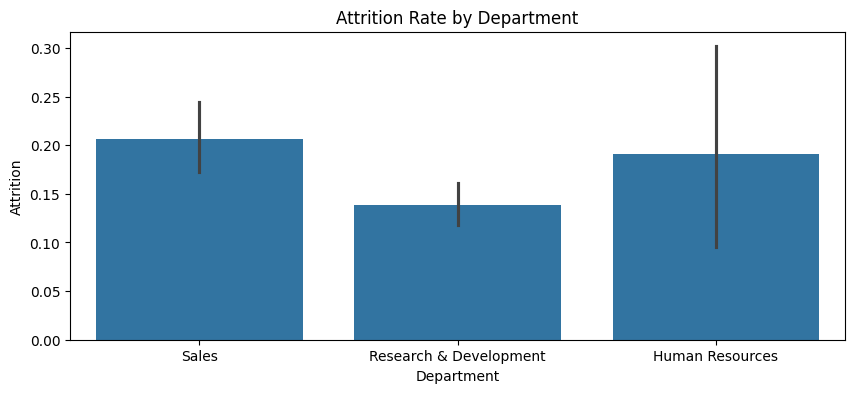

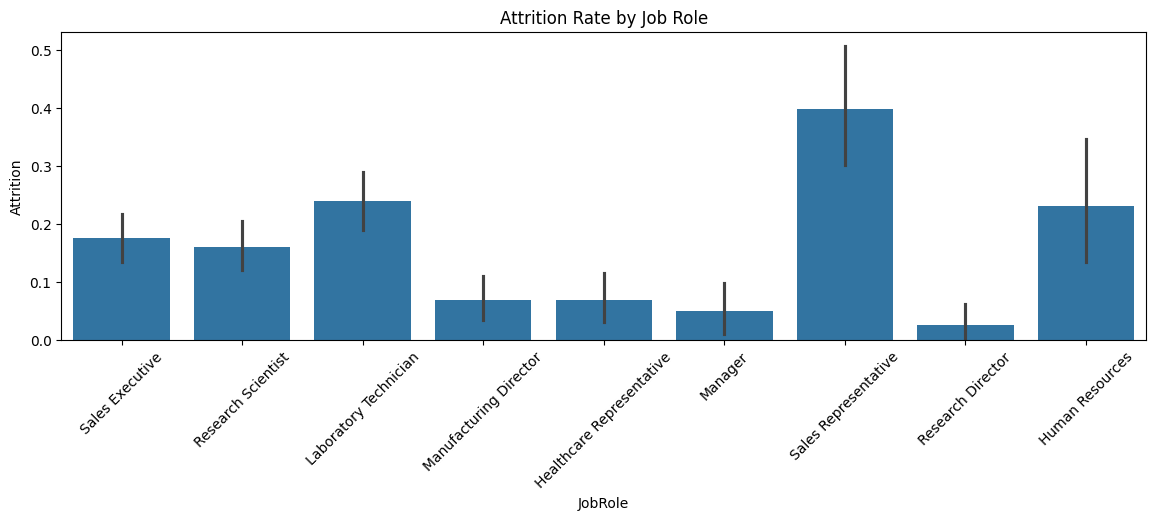

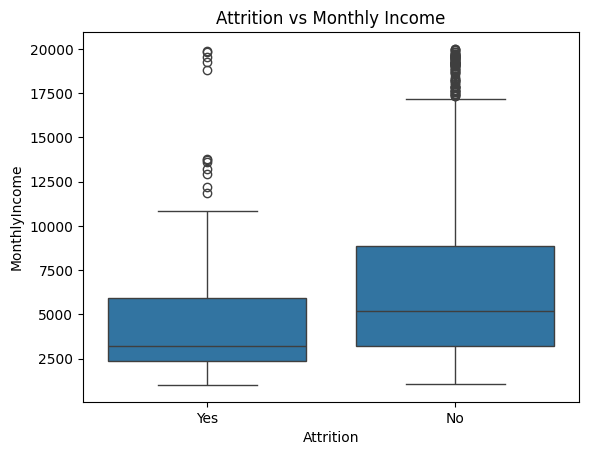

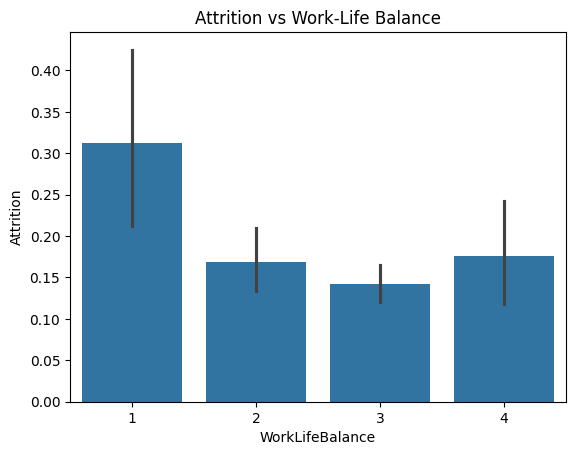

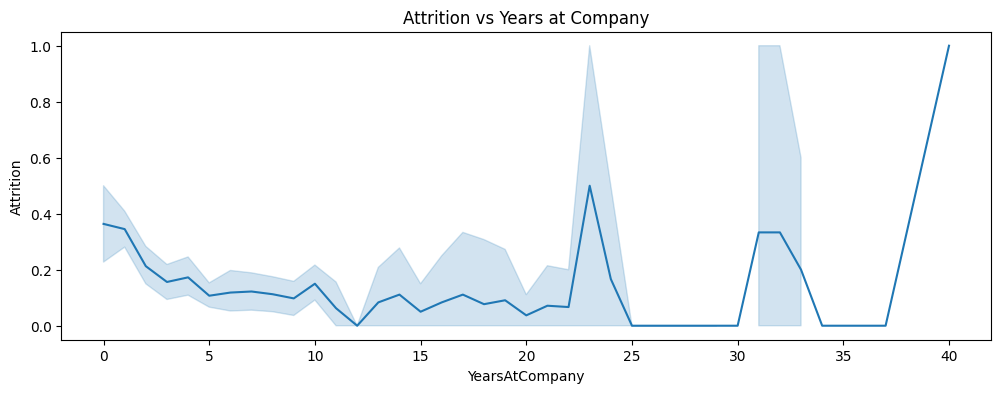

In [3]:
plt.figure(figsize=(10,4))
sns.barplot(x=df['Department'], y=df_clean['Attrition'])
plt.title('Attrition Rate by Department')
plt.show()

plt.figure(figsize=(14,4))
sns.barplot(x=df['JobRole'], y=df_clean['Attrition'])
plt.xticks(rotation=45)
plt.title('Attrition Rate by Job Role')
plt.show()

sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title('Attrition vs Monthly Income')
plt.show()

sns.barplot(x='WorkLifeBalance', y='Attrition', data=df_clean)
plt.title('Attrition vs Work-Life Balance')
plt.show()

plt.figure(figsize=(12,4))
sns.lineplot(x='YearsAtCompany', y='Attrition', data=df_clean)
plt.title('Attrition vs Years at Company')
plt.show()


### Business Insights from EDA
1. **Department Attrition**: Sales experiences the highest attrition rate at 20.6%.
2. **Job Role Attrition**: Sales Representative roles have the highest exit rate (39.8%), indicating possible burnout or dissatisfaction in this specific role.
3. **Monthly Income**: Employees who leave generally have a lower median monthly income compared to those who stay.
4. **Work-Life Balance**: Lower work-life balance scores correlate with higher attrition rates.
5. **Tenure (Years at Company)**: Most attrition happens in the first few years (0-2 years), suggesting onboarding or early-career retention issues.


## Task 4 — Model Building & Comparison

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X_scaled_df, y, test_size=0.2, random_state=42, stratify=y)

models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    res = {
        "Model": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    }
    results.append(res)
    trained_models[name] = model

results_df = pd.DataFrame(results)
display(results_df)


,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.341176,0.617021,0.439394,0.798605
1,Random Forest,0.375000,0.063830,0.109091,0.756784
2,Gradient Boosting,0.588235,0.212766,0.312500,0.794125


## Task 5 & 6 — Model Evaluation & Visualizations

The best performing model is: Logistic Regression


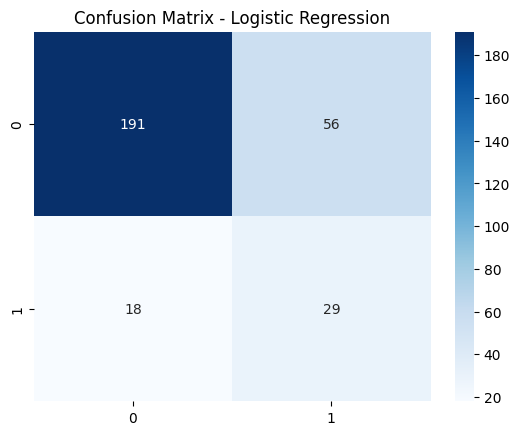

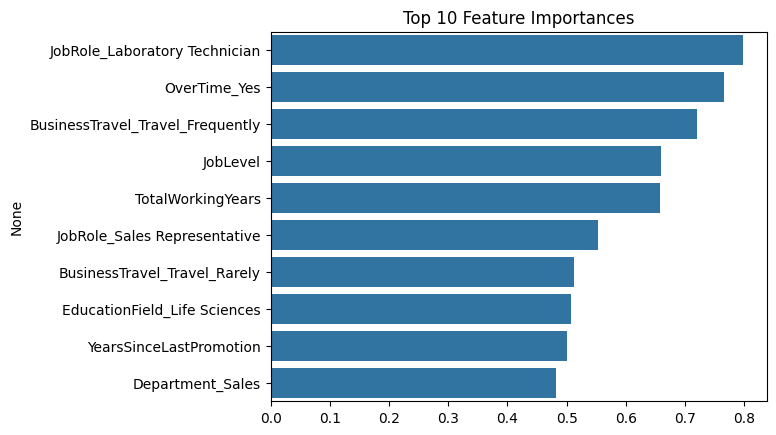

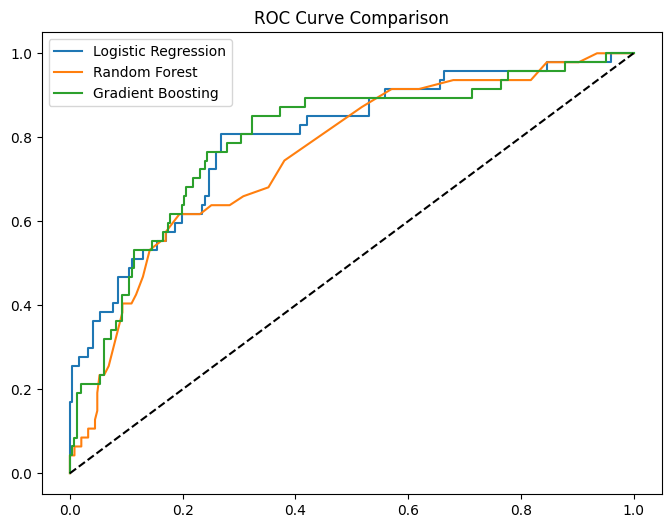

In [5]:
best_model_name = results_df.loc[results_df['ROC-AUC'].idxmax()]['Model']
best_model = trained_models[best_model_name]
print(f"The best performing model is: {best_model_name}")

y_pred_best = best_model.predict(X_test)

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

# Feature Importances
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importances = np.abs(best_model.coef_[0])

feat_imp = pd.Series(importances, index=X_scaled_df.columns).sort_values(ascending=False).head(10)
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title('Top 10 Feature Importances')
plt.show()

# ROC Curve comparison
from sklearn.metrics import roc_curve
plt.figure(figsize=(8,6))
for name, model in trained_models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=name)
plt.plot([0,1], [0,1], 'k--')
plt.legend()
plt.title('ROC Curve Comparison')
plt.show()


## Task 7 — HR Insights & Business Recommendations

### HR Insights & Business Recommendations

**Which 3 factors most strongly predict that an employee will leave?**
Based on the Logistic Regression model, the top 3 factors driving attrition are JobRole_Laboratory Technician, OverTime_Yes, and BusinessTravel_Travel_Frequently.

**Which department or job role should HR prioritize for retention efforts?**
HR should focus strongly on the Sales department and particularly the Sales Representative roles, as they exhibit the highest exit rates.

**Does salary alone explain attrition or are there other stronger factors?**
While Monthly Income is a factor, it does not act alone. Factors like OverTime, Job Satisfaction, and Years At Company are also crucial predictors. Employees often leave due to a combination of high workload (OverTime) and low satisfaction, not just pay.

**Recommendations:**
1. **Targeted Check-ins:** Implement mandatory retention conversations or check-ins with employees in Sales Representative roles, especially those working frequent OverTime or in their first two years.
2. **Workload and Satisfaction Review:** For roles with high attrition, review compensation structures alongside workload expectations to improve work-life balance and overall job satisfaction.

**Model Limitations:**
This model is trained on historical snapshot data and assumes past trends will continue. It does not capture qualitative reasons for leaving (e.g., specific manager conflicts, external life events) and should be used as a guiding tool rather than an absolute truth.
